# INSEE's premises

In [1]:
import geopandas
import re
import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib, descartes

from pynsee.sirene import *
from pynsee.geodata import *

In [2]:
# Subscribe to api.insee.fr and get your credentials!
# Save your credentials with init_conn function :
# from pynsee.utils.init_conn import init_conn
# init_conn(insee_key="my_insee_key", insee_secret="my_insee_secret")

# Beware : any change to the keys should be tested after having cleared the cache
# Please do : from pynsee.utils import clear_all_cache; clear_all_cache()"

In [3]:
variable = ["denominationUniteLegale", 'sigleUniteLegale', 'categorieJuridiqueUniteLegale']

insee_pattern = "INSTITUT NATIONAL DE LA STATISTIQUE ET DES ETUDES ECONOMIQUES"
pattern = [insee_pattern, 'INSEE', '7120']
# 7120 : Service central d'un ministère

data = search_sirene(variable = variable, pattern = pattern, kind="siret")

# remove overseas department premises
data = data[~(data['codePostalEtablissement'].str.contains('^97'))]
data = data.reset_index(drop=True)

Getting legal entities: 100%|██████████| 1/1 [00:00<00:00,  5.01it/s]


!!! This function may return personal data, please check and
 comply with the legal framework relating to personal data protection !!!


In [4]:
df = data.get_location()
df.head()

!!!
This function relies on OpenStreetMap
Please, change timeSleep argument if the maximum number of queries is reached
Beware, maintenance of this function should not be taken for granted!
!!!


Getting location: 100%|██████████| 32/32 [00:16<00:00,  1.91it/s]


,siren,nic,siret,dateDebut,dateCreationEtablissement,dateCreationUniteLegale,denominationUniteLegale,categorieEntreprise,categorieJuridiqueUniteLegale,categorieJuridiqueUniteLegaleLibelle,...,nomenclatureActivitePrincipaleEtablissement,changementActivitePrincipaleEtablissement,caractereEmployeurEtablissement,changementCaractereEmployeurEtablissement,latitude,longitude,category,type,importance,geometry
0,120027016,00431,12002701600431,2016-09-01,2016-09-01,1983-03-01,INSTITUT NATIONAL DE LA STATISTIQUE ET DES ETU...,GE,7120,Service central d'un ministère,...,NAFRev2,False,N,False,43.283921,5.392697,office,government,0.621,POINT (5.3926966 43.2839208)
1,120027016,00233,12002701600233,2016-09-01,2016-09-01,1983-03-01,INSTITUT NATIONAL DE LA STATISTIQUE ET DES ETU...,GE,7120,Service central d'un ministère,...,NAFRev2,False,N,False,48.788172,2.047440,place,house,0.821,POINT (2.04744 48.788172)
2,120027016,00167,12002701600167,2008-01-01,1996-04-15,1983-03-01,INSTITUT NATIONAL DE LA STATISTIQUE ET DES ETU...,GE,7120,Service central d'un ministère,...,NAFRev2,True,O,False,44.919632,-0.243154,highway,residential,0.810,POINT (-0.2431541 44.9196319)
3,120027016,00464,12002701600464,2016-09-01,2016-09-01,1983-03-01,INSTITUT NATIONAL DE LA STATISTIQUE ET DES ETU...,GE,7120,Service central d'un ministère,...,NAFRev2,False,N,False,41.947013,8.753904,highway,residential,0.710,POINT (8.7539038 41.9470135)
4,120027016,00480,12002701600480,2016-09-01,2016-09-01,1983-03-01,INSTITUT NATIONAL DE LA STATISTIQUE ET DES ETU...,GE,7120,Service central d'un ministère,...,NAFRev2,False,N,False,47.321871,5.022720,place,house,0.621,POINT (5.0227199 47.3218708)


In [5]:
gdf = geopandas.GeoDataFrame(df)
gdf = gdf.reset_index(drop=True)

for i in range(len(gdf.index)):
    gdf.loc[i,'name'] = str(i+1) + ' - ' + gdf.loc[i,'enseigne1Etablissement']
    gdf.loc[i,'i'] = i + 1
    
# cleaning
gdf = gdf[~gdf.geometry.isnull()]

In [6]:
geodataList =  get_geodata_list()
mapdep = get_geodata('ADMINEXPRESS-COG-CARTO.LATEST:departement')

Previously saved data used
/home/jovyan/.cache/insee/pynsee/2ac583be54e866b2b1b30fb0113c1fd0.csv
Set update=True to get the most up-to-date data
Previously saved data used
/home/jovyan/.cache/insee/pynsee/a28d68dc88fcd55fe62626ea25a1760a.csv
Set update=True to get the most up-to-date data


In [7]:
# remove overseas departments
mapdep = mapdep[~mapdep['insee_dep'].isin(['971', '972', '973', '974', '976'])]
# conversion to geopandas df
mapdepgeo = geopandas.GeoDataFrame(mapdep).set_crs("EPSG:4326")
mapdepgeo.head()

,id,nom_m,nom,insee_dep,insee_reg,geometry,bbox
0,DEPARTEM_FXX_00000000001,AIN,Ain,01,84,"MULTIPOLYGON (((4.79539 46.22007, 4.79676 46.2...","[4.72806849, 45.61108636, 6.17003068, 46.51991..."
1,DEPARTEM_FXX_00000000002,AISNE,Aisne,02,32,"MULTIPOLYGON (((3.12080 49.70572, 3.12052 49.7...","[2.95803556, 48.83720744, 4.25583685, 50.06949..."
2,DEPARTEM_FXX_00000000003,HAUTE-CORSE,Haute-Corse,2B,94,"MULTIPOLYGON (((9.47096 42.98463, 9.47126 42.9...","[8.57330539, 41.83218234, 9.56009361, 43.02769..."
3,DEPARTEM_FXX_00000000004,CORSE-DU-SUD,Corse-du-Sud,2A,94,"MULTIPOLYGON (((8.59798 41.88006, 8.59798 41.8...","[8.53468641, 41.33355569, 9.40803974, 42.3815338]"
4,DEPARTEM_FXX_00000000005,ALLIER,Allier,03,84,"MULTIPOLYGON (((2.53665 46.51970, 2.53717 46.5...","[2.2767858, 45.93072787, 4.00573657, 46.80428705]"


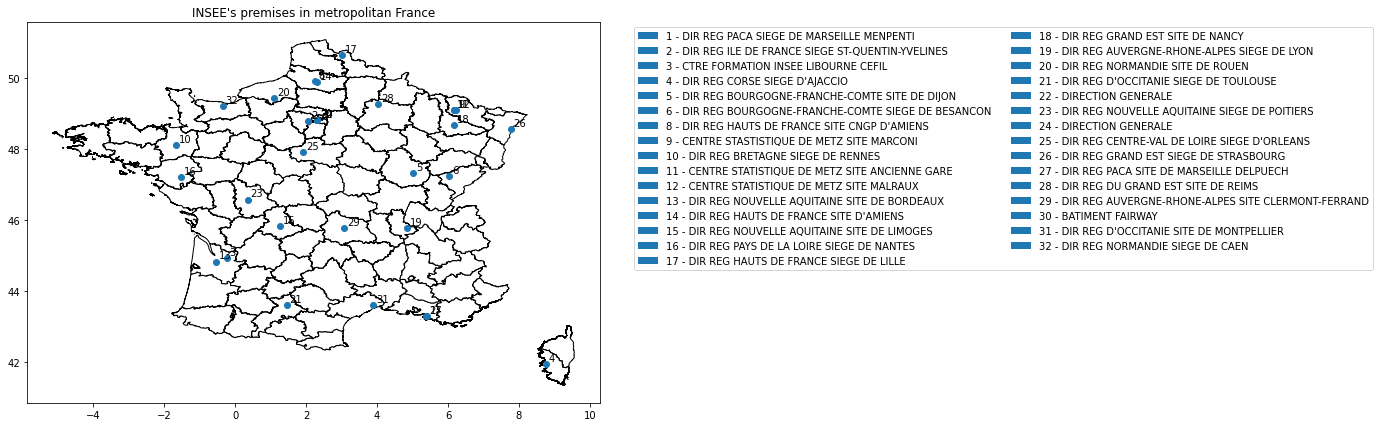

In [8]:
# plot
ax = mapdepgeo.plot(color='white', edgecolor='black', figsize = (15,7))

gdf.plot(ax=ax)
plt.title("INSEE's premises in metropolitan France")

for x, y, i, label in zip(gdf.geometry.x, gdf.geometry.y, gdf.i, gdf.name):
    ax.annotate(int(i), xy=(x, y), xytext=(3, 3), textcoords="offset points")

legends = [mpatches.Patch(label=f) for f in gdf.name]
plt.legend(handles=legends, ncol=2, bbox_to_anchor=(1.05, 1))